# Question 8  
We will now perform cross-validation on a simulated data set.

### (a)  
Generate a simulated data set as follows:

```python
import numpy as np
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
```

In this data set, what is \( n \)? Write out the model used to generate the data in equation form.  

In [ ]:
import numpy as np
rng = np.random.default_rng(1) # rng = random number generator
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

### (b)  
Create a scatterplot of \( X \) against \( Y \). Comment on what you find.

```python
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X vs Y")
plt.show()
```

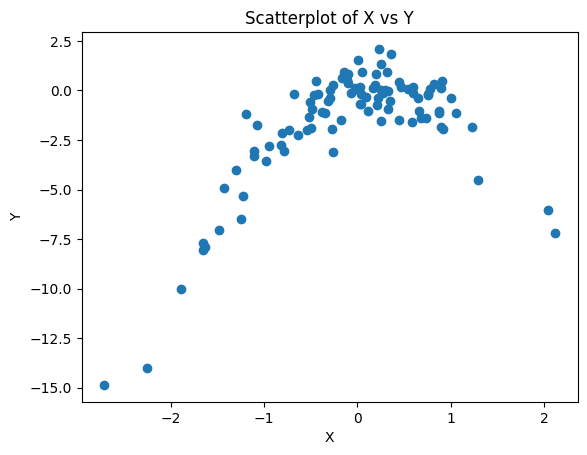

In [10]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X vs Y")
plt.show()

### (c)   
Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:  
i. \( Y = \beta_0 + \beta_1 X + \epsilon \)  
ii. \( Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon \)  
iii. \( Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon \)  
iv. \( Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \epsilon \)  

Note you may find it helpful to use the `pd.DataFrame()` function to create a single data set containing both \( X \) and \( Y \).  

In [11]:
import pandas as pd

df = pd.DataFrame({
    "x": x,
    "x2": x**2,
    "x3": x**3,
    "x4": x**4,
    "y": y
})

In [17]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression

loo = LeaveOneOut()

def loocv_error(feature):
    X = df[feature].values
    y = df["y"].values
    errors = []

    for train_idx, test_idx in loo.split(X):
        model = LinearRegression().fit(X[train_idx],y[train_idx])
        pred = model.predict(X[test_idx])
        errors.append((y[test_idx]-pred)**2)
    return np.mean(errors)

err1 = loocv_error(["x"])
err2 = loocv_error(["x", "x2"])
err3 = loocv_error(["x", "x2", "x3"])
err4 = loocv_error(["x", "x2", "x3", "x4"])

print("LOOCV errors:")
print(f"Degree 1: {err1:.3f}")
print(f"Degree 2: {err2:.3f}")
print(f"Degree 3: {err3:.3f}")
print(f"Degree 4: {err4:.3f}")

LOOCV errors:
Degree 1: 6.633
Degree 2: 1.123
Degree 3: 1.302
Degree 4: 1.332


### (d)  
Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?  

In [28]:
import numpy as np
rng = np.random.default_rng(16) # using another random seed here!
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In [29]:
import pandas as pd

df = pd.DataFrame({
    "x": x,
    "x2": x**2,
    "x3": x**3,
    "x4": x**4,
    "y": y
})

In [26]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression

loo = LeaveOneOut()

def loocv_error(feature):
    X = df[feature].values
    y = df["y"].values
    errors = []

    for train_idx, test_idx in loo.split(X):
        model = LinearRegression().fit(X[train_idx],y[train_idx])
        pred = model.predict(X[test_idx])
        errors.append((y[test_idx]-pred)**2)
    return np.mean(errors)

err1 = loocv_error(["x"])
err2 = loocv_error(["x", "x2"])
err3 = loocv_error(["x", "x2", "x3"])
err4 = loocv_error(["x", "x2", "x3", "x4"])

print("LOOCV errors:")
print(f"Degree 1: {err1:.3f}")
print(f"Degree 2: {err2:.3f}")
print(f"Degree 3: {err3:.3f}")
print(f"Degree 4: {err4:.3f}")

LOOCV errors:
Degree 1: 9.318
Degree 2: 1.056
Degree 3: 1.041
Degree 4: 1.050


**ANS for question d:**  
The degree-1 model shows the largest variation between the two runs, indicating that an under-specified model is more sensitive to noise. In contrast, the degree-2 to degree-4 models show only minor differences, and their overall ranking remains similar.

### (e)  
Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.  

**ANS for question e:**  
I expect that the degree-2 model will have the smallest LOOCV error because that's how we generate x and y in the beginning.

### (f)  
Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

In [32]:
import statsmodels.api as sm

X = df[['x','x2','x3','x4']]
y = df['y']

X = sm.add_constant(X)
model =sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     216.8
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           7.51e-47
Time:                        21:32:33   Log-Likelihood:                -140.04
No. Observations:                 100   AIC:                             290.1
Df Residuals:                      95   BIC:                             303.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1552      0.151     -1.029      0.3

**ANS for question f:**  
Based on the summary, we can see that the p-values of x and x2 are below 0.05, indicating that these predictors are statistically significant for the prediction. In contrast, the p-values of x3 and x4 are above 0.05, which means they do not have a significant impact on the prediction.
